First 5 rows of the dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  

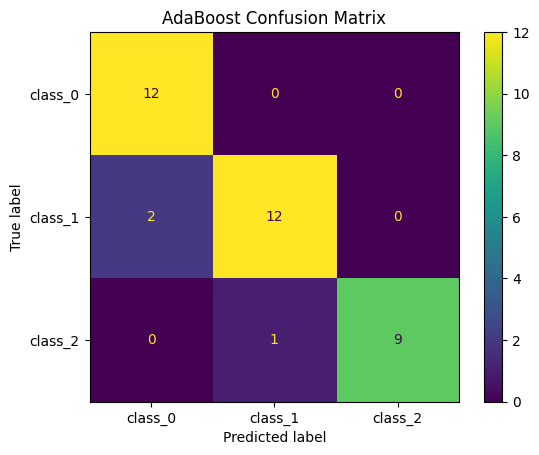

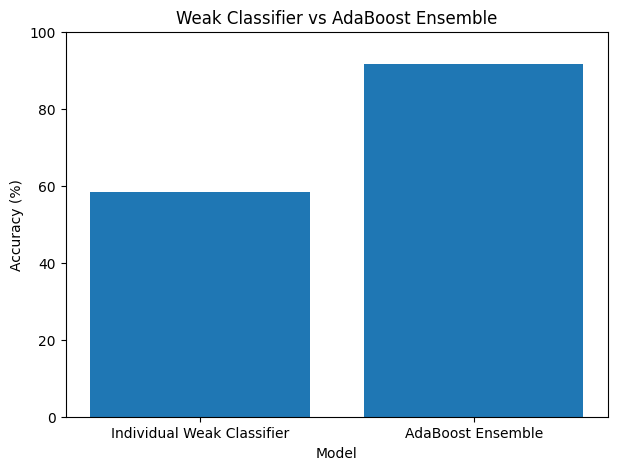

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# --------------------------------------------------
# Loading the Wine Dataset
# --------------------------------------------------

wine = load_wine()

# Input features
X = wine.data

# Target/output classes
y = wine.target

# Creating a DataFrame to display the dataset
dataset = pd.DataFrame(X, columns=wine.feature_names)

print("First 5 rows of the dataset:")
print(dataset.head())

print("\nTarget Classes:")
for i, class_name in enumerate(wine.target_names):
    print(i, "=", class_name)

print("\n" + "=" * 60)

# --------------------------------------------------
# Splitting the Dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Creating an Individual Weak Classifier
# --------------------------------------------------

weak_classifier = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

# Training the weak classifier
weak_classifier.fit(X_train, y_train)

# Predictions from the weak classifier
weak_pred = weak_classifier.predict(X_test)

# Calculating weak classifier accuracy
weak_accuracy = accuracy_score(y_test, weak_pred)

print("Individual Weak Classifier Accuracy:",
      weak_accuracy * 100, "%")

print("\n" + "=" * 60)

# --------------------------------------------------
# Creating the AdaBoost Ensemble Model
# --------------------------------------------------

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Training the AdaBoost model
ada_model.fit(X_train, y_train)

# Making predictions
ada_pred = ada_model.predict(X_test)

# Calculating AdaBoost accuracy
ada_accuracy = accuracy_score(y_test, ada_pred)

print("AdaBoost Ensemble Accuracy:",
      ada_accuracy * 100, "%")

print("\n" + "=" * 60)

# --------------------------------------------------
# Comparing the Results
# --------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Individual Weak Classifier",
        "AdaBoost Ensemble"
    ],
    "Accuracy (%)": [
        weak_accuracy * 100,
        ada_accuracy * 100
    ]
})

print("Model Comparison:")
print(comparison)

print("\n" + "=" * 60)

# --------------------------------------------------
# AdaBoost Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(y_test, ada_pred)

print("AdaBoost Confusion Matrix:")
print(cm)

print("\n" + "=" * 60)

# --------------------------------------------------
# Classification Report
# --------------------------------------------------

print("AdaBoost Classification Report:")
print(
    classification_report(
        y_test,
        ada_pred,
        target_names=wine.target_names
    )
)

# --------------------------------------------------
# Visualizing the Confusion Matrix
# --------------------------------------------------

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wine.target_names
)

display.plot()

plt.title("AdaBoost Confusion Matrix")

plt.show()

# --------------------------------------------------
# Visualizing Accuracy Comparison
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Weak Classifier vs AdaBoost Ensemble")

plt.ylim(0, 100)

plt.show()